# **Ejercicio 1 — Filtrado Pasa Banda**
Genere tres señales:
5 Hz, 20 Hz y 80 Hz. Diseñe un filtro pasa banda que permita únicamente:
15 Hz a 30 Hz
Presente: Señal temporal y FFT antes/después

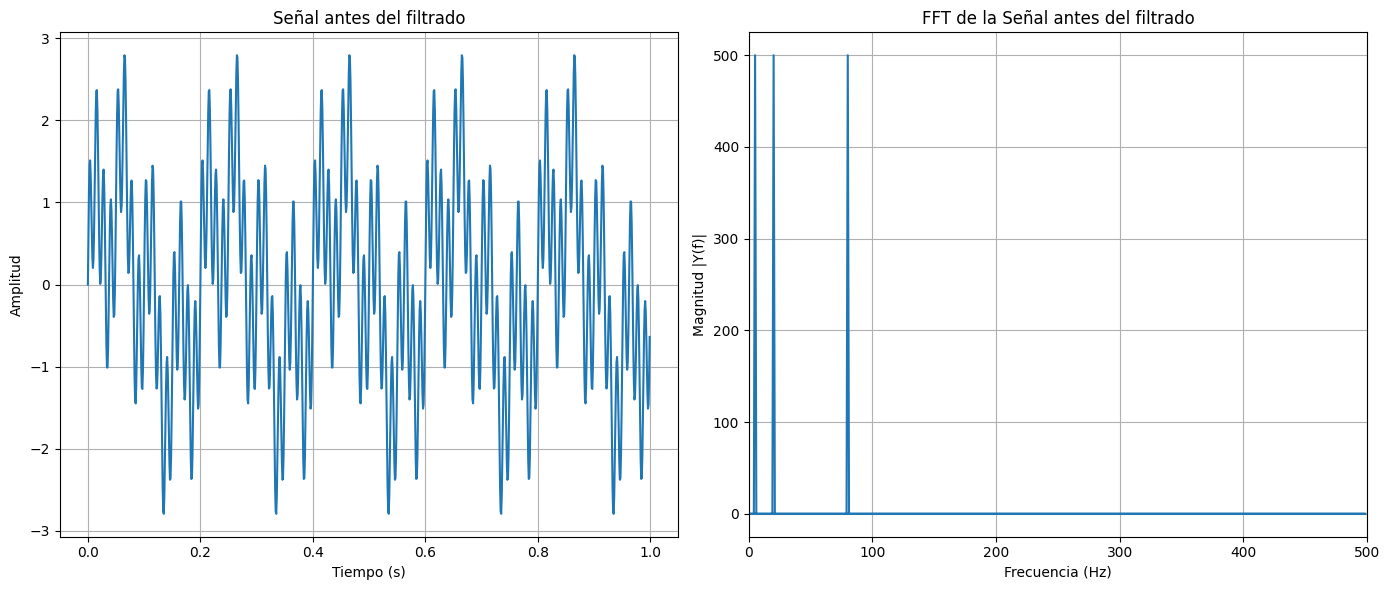

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, freqz

fs = 1000  # Frecuencia de muestreo (Hz)
t_duration = 1  # Duración de la señal (segundos)
t = np.linspace(0, t_duration, int(fs * t_duration), endpoint=False)

# Frecuencias de las señales senoidales
f1 = 5   # Hz
f2 = 20  # Hz
f3 = 80  # Hz

# Generar las señales
s1 = np.sin(2 * np.pi * f1 * t)
s2 = np.sin(2 * np.pi * f2 * t)
s3 = np.sin(2 * np.pi * f3 * t)

# Señal compuesta
signal = s1 + s2 + s3

# Plot de la señal temporal antes del filtrado
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(t, signal)
plt.title('Señal antes del filtrado')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

# Calcular y plotear la FFT de la señal compuesta
N = len(signal) # Número de puntos en la señal
Y = np.fft.fft(signal)
freq = np.fft.fftfreq(N, 1/fs)

plt.subplot(1, 2, 2)
plt.plot(freq, np.abs(Y))
plt.title('FFT de la Señal antes del filtrado')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud |Y(f)|')
plt.xlim(0, fs/2) # Mostrar solo frecuencias positivas hasta Nyquist
plt.grid(True)
plt.tight_layout()
plt.show()

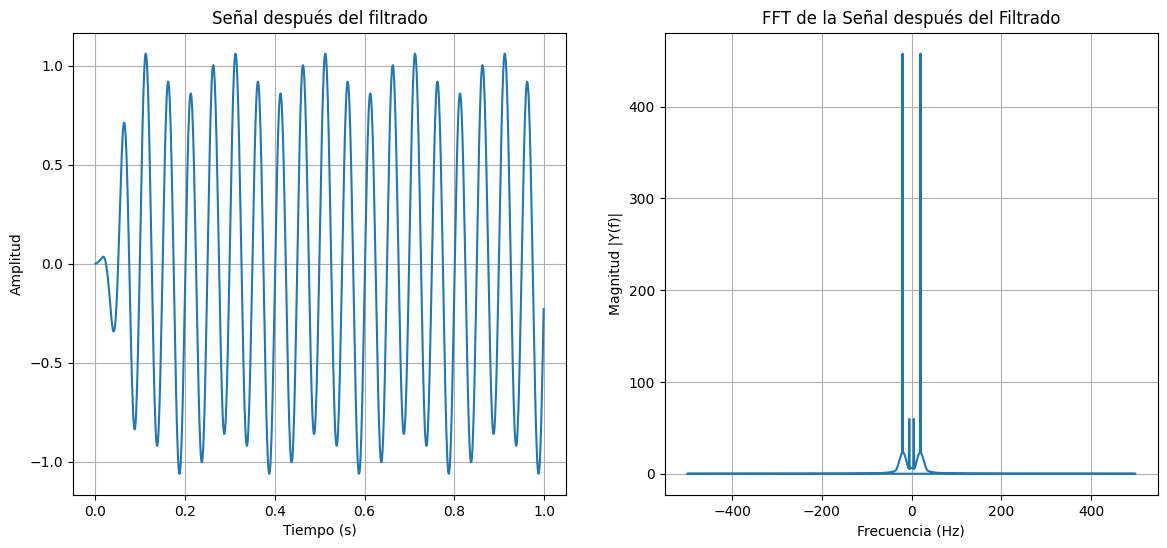

In [ ]:
from scipy.signal import firwin, lfilter

numtaps = 101

# Frecuencias de corte del filtro pasa banda (15 Hz a 30 Hz)

fir_coeffs = firwin(
    numtaps,
    [15, 30],
    pass_zero=False,  # Indica que es un filtro pasa banda
    fs=fs,
    window='hamming'
)

# Aplicar el filtro a la señal compuesta
filtered_signal_fir = lfilter(fir_coeffs, 1.0, signal)

# Plot de la señal temporal después del filtrado
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(t, filtered_signal_fir)
plt.title('Señal después del filtrado')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

# Calcular y plotear la FFT de la señal filtrada
N_filtered = len(filtered_signal_fir)
Y_filtered = np.fft.fft(filtered_signal_fir)
freq_filtered = np.fft.fftfreq(N_filtered, 1/fs)

plt.subplot(1, 2, 2)
plt.plot(freq_filtered, np.abs(Y_filtered))
plt.title('FFT de la Señal después del Filtrado')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud |Y(f)|')
plt.grid(True)
plt.show()

# **Ejercicio 2 — Eliminación de Ruido Blanco**
Genere:
*   ECG sintético
*   ruido blanco
*   interferencia de alta frecuencia

Diseñe:
*   lowpass
*   bandpass

In [3]:
!pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 15.1 MB/s eta 0:00:00


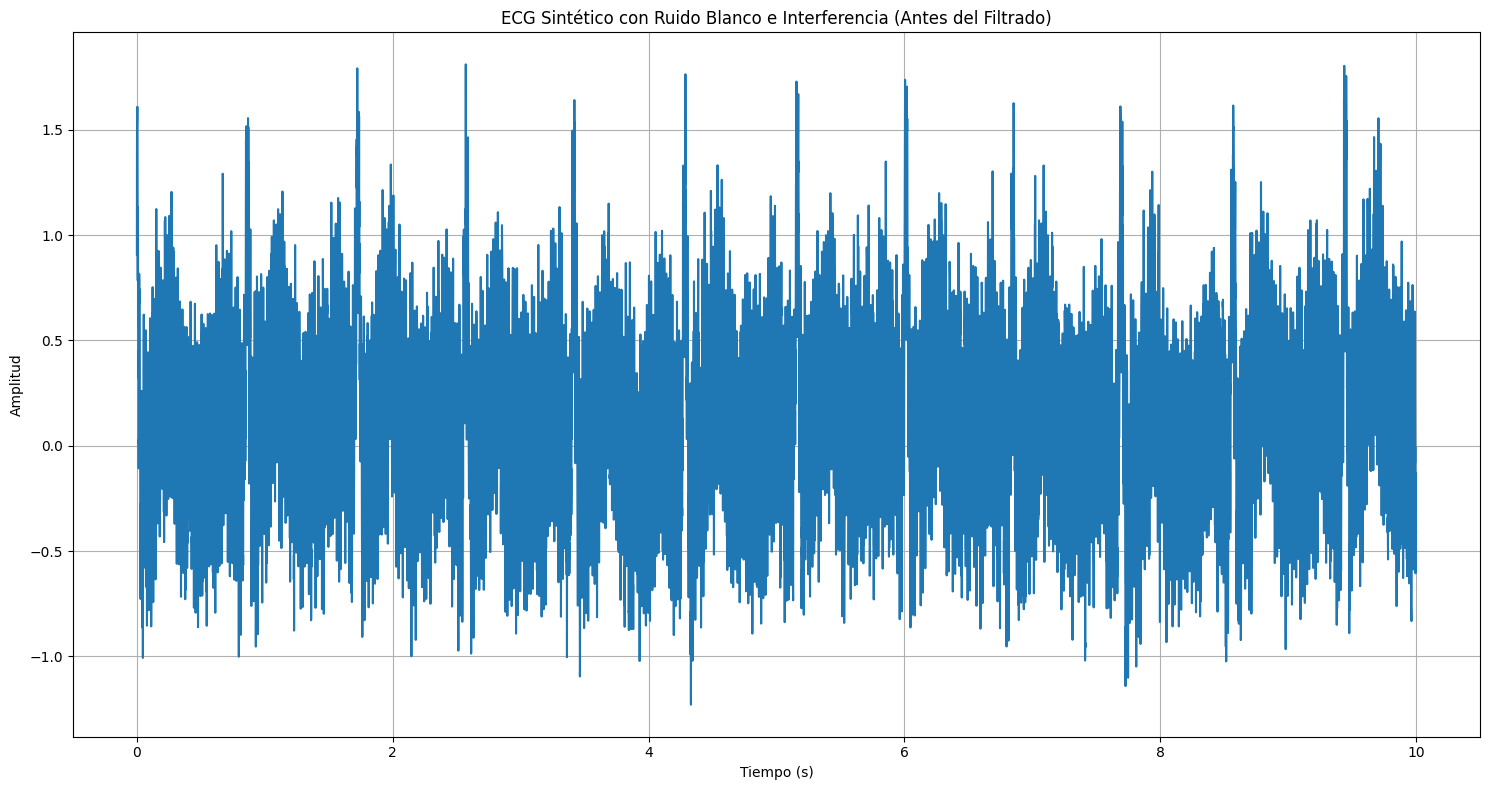

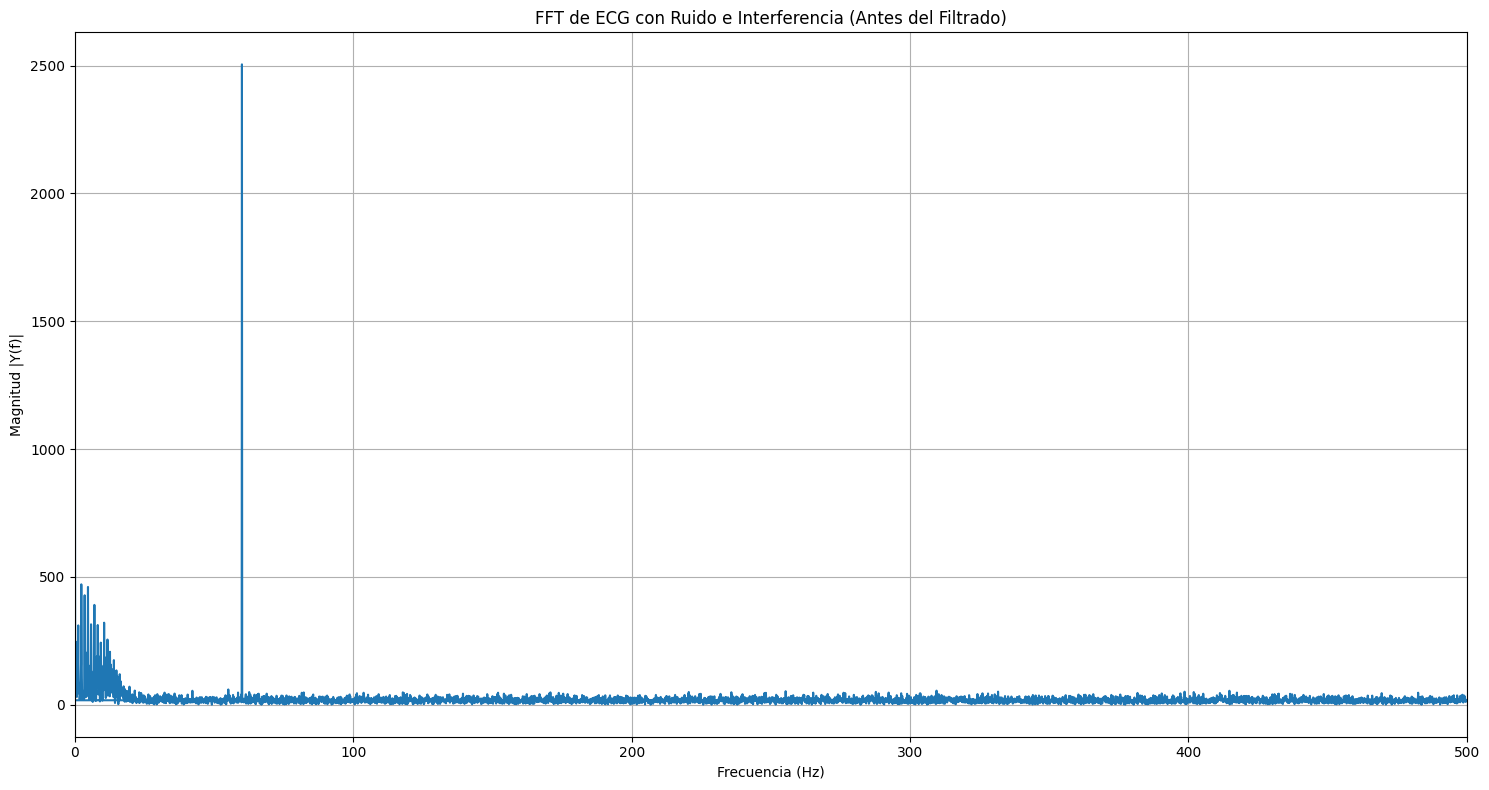

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, freqz, lfilter, firwin
import neurokit2 as nk


fs = 1000  # Frecuencia de muestreo (Hz)
t_duration_ecg = 10
t_ecg = np.linspace(0, t_duration_ecg, int(fs * t_duration_ecg), endpoint=False)

# ECG sintético con NeuroKit2
ecgsignal = nk.ecg_simulate(duration=t_duration_ecg, sampling_rate=fs, heart_rate=70, method='ecgsyn')

# Asegurarse de que la longitud de t y ecgsignal coincida
if len(t_ecg) > len(ecgsignal):
    t_ecg = t_ecg[:len(ecgsignal)]
elif len(ecgsignal) > len(t_ecg):
    ecgsignal = ecgsignal[:len(t_ecg)]

# Ruido blanco
white_noise = 0.2 * np.random.randn(len(ecgsignal))

# Interferencia de alta frecuencia
f_interference = 60
high_freq_interference = 0.5 * np.sin(2 * np.pi * f_interference * t_ecg)

# Señal combinada (ECG con ruido e interferencia)
noisy_ecg = ecgsignal + white_noise + high_freq_interference

# Plot de la señal temporal antes del filtrado
plt.figure(figsize=(15, 8))
plt.plot(t_ecg, noisy_ecg)
plt.title('ECG Sintético con Ruido Blanco e Interferencia (Antes del Filtrado)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.tight_layout()
plt.show()

# Calcular y plotear la FFT de la señal combinada
N_ecg = len(noisy_ecg)
Y_ecg = np.fft.fft(noisy_ecg)
freq_ecg = np.fft.fftfreq(N_ecg, 1/fs)

plt.figure(figsize=(15, 8))
plt.plot(freq_ecg, np.abs(Y_ecg))
plt.title('FFT de ECG con Ruido e Interferencia (Antes del Filtrado)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud |Y(f)|')
plt.xlim(0, fs/2)
plt.grid(True)
plt.tight_layout()
plt.show()

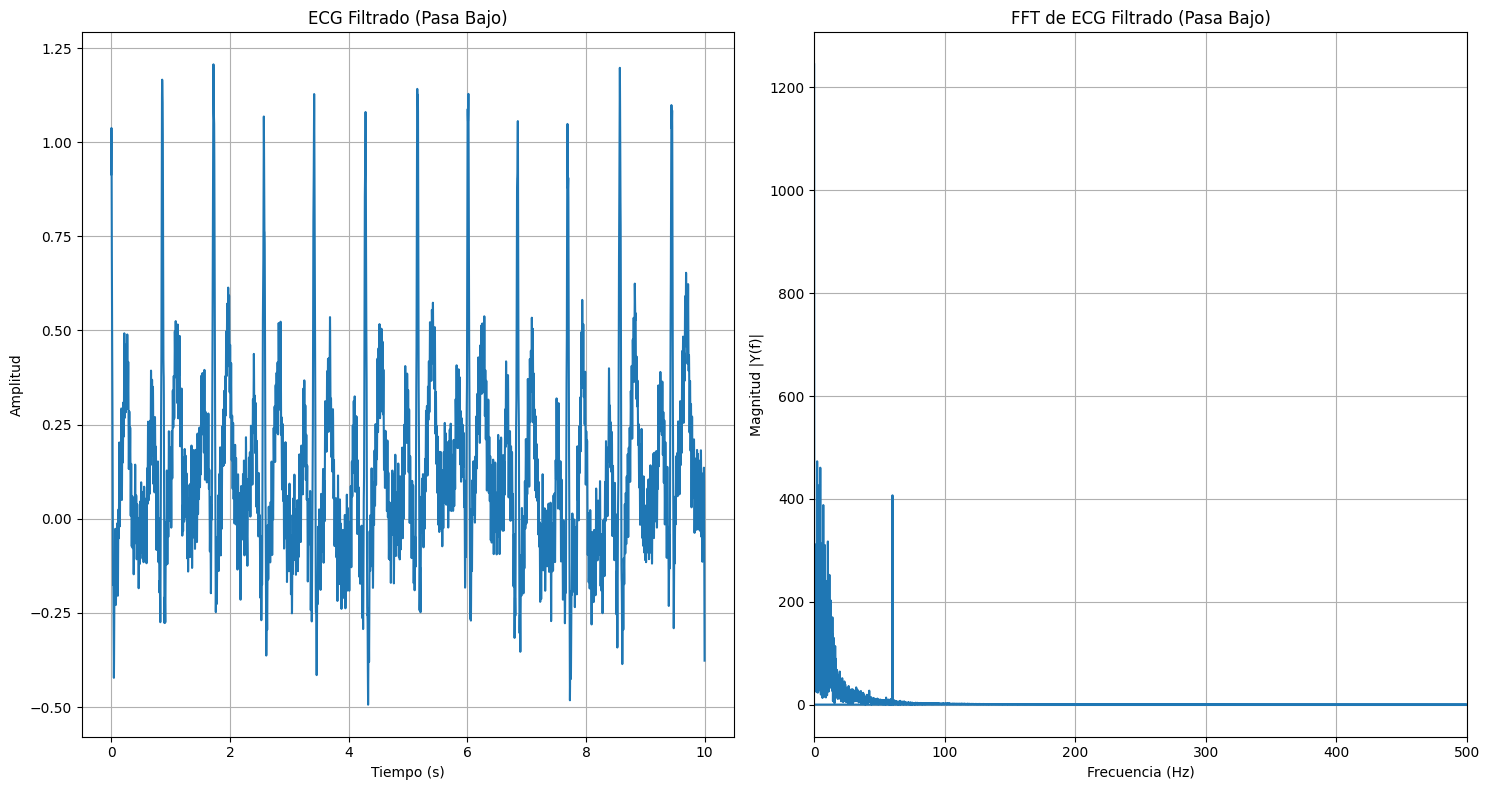

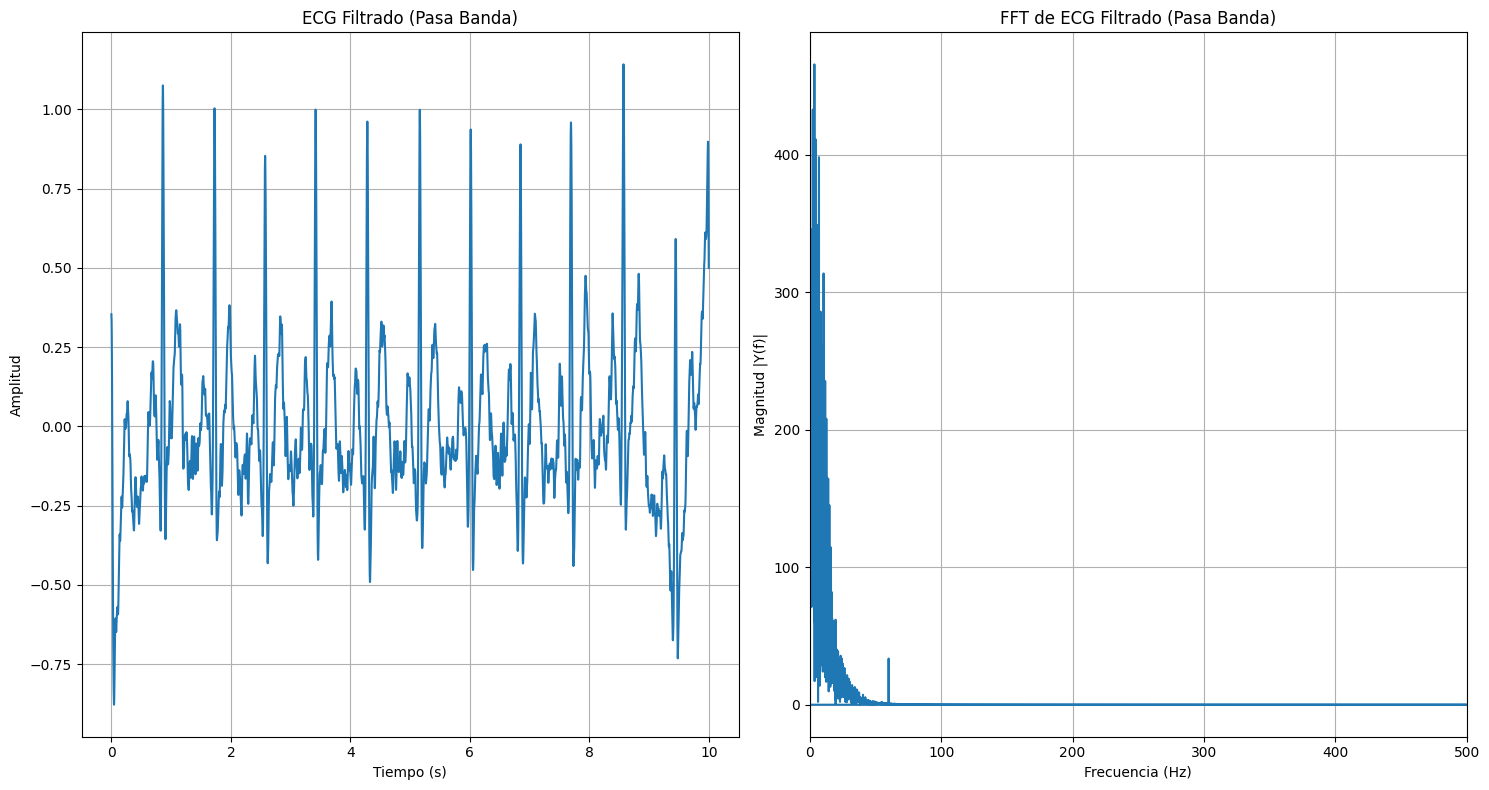

In [8]:
# filtro Lowpass

lowcut_lp = 40.0  # Frecuencia de corte para el pasa bajo (Hz)
order_lp = 2     # Orden del filtro

nyquist = 0.5 * fs


b_lp, a_lp = butter(order_lp, lowcut_lp, btype='low', fs=fs)

filtered_ecg_lp = filtfilt(b_lp, a_lp, noisy_ecg)

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.plot(t_ecg, filtered_ecg_lp)
plt.title('ECG Filtrado (Pasa Bajo)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

# Calcular y plotear la FFT de la señal filtrada con pasa bajo
Y_ecg_lp = np.fft.fft(filtered_ecg_lp)
plt.subplot(1, 2, 2)
plt.plot(freq_ecg, np.abs(Y_ecg_lp))
plt.title('FFT de ECG Filtrado (Pasa Bajo)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud |Y(f)|')
plt.xlim(0, fs/2)
plt.grid(True)
plt.tight_layout()
plt.show()

# Filtro Bandpass
lowcut_bp = 0.5   # Frecuencia de corte inferior para el pasa banda (Hz)
highcut_bp = 30.0 # Frecuencia de corte superior para el pasa banda (Hz)
order_bp = 3    # Orden del filtro


b_bp, a_bp = butter(order_bp, [lowcut_bp, highcut_bp], btype='band', fs=fs)

# aplicaré el filtro en la señal original para ver su efecto vs el efecto del filtro lowpass
filtered_ecg_bp = filtfilt(b_bp, a_bp, noisy_ecg)

# Plot de la señal temporal después del filtro pasa banda
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.plot(t_ecg, filtered_ecg_bp)
plt.title('ECG Filtrado (Pasa Banda)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

# Calcular y plotear la FFT de la señal filtrada con pasa banda
Y_ecg_bp = np.fft.fft(filtered_ecg_bp)
plt.subplot(1, 2, 2)
plt.plot(freq_ecg, np.abs(Y_ecg_bp))
plt.title('FFT de ECG Filtrado (Pasa Banda)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud |Y(f)|')
plt.xlim(0, fs/2)
plt.grid(True)
plt.tight_layout()
plt.show()

# **Ejercicio 3 — Ruido Impulsivo**
Genere:
*   señal EEG simulada
*   10 spikes aleatorios
Compare:
*   FIR lowpass
*   filtro mediana

Explique cuál funciona mejor.

In [10]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 39.5 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


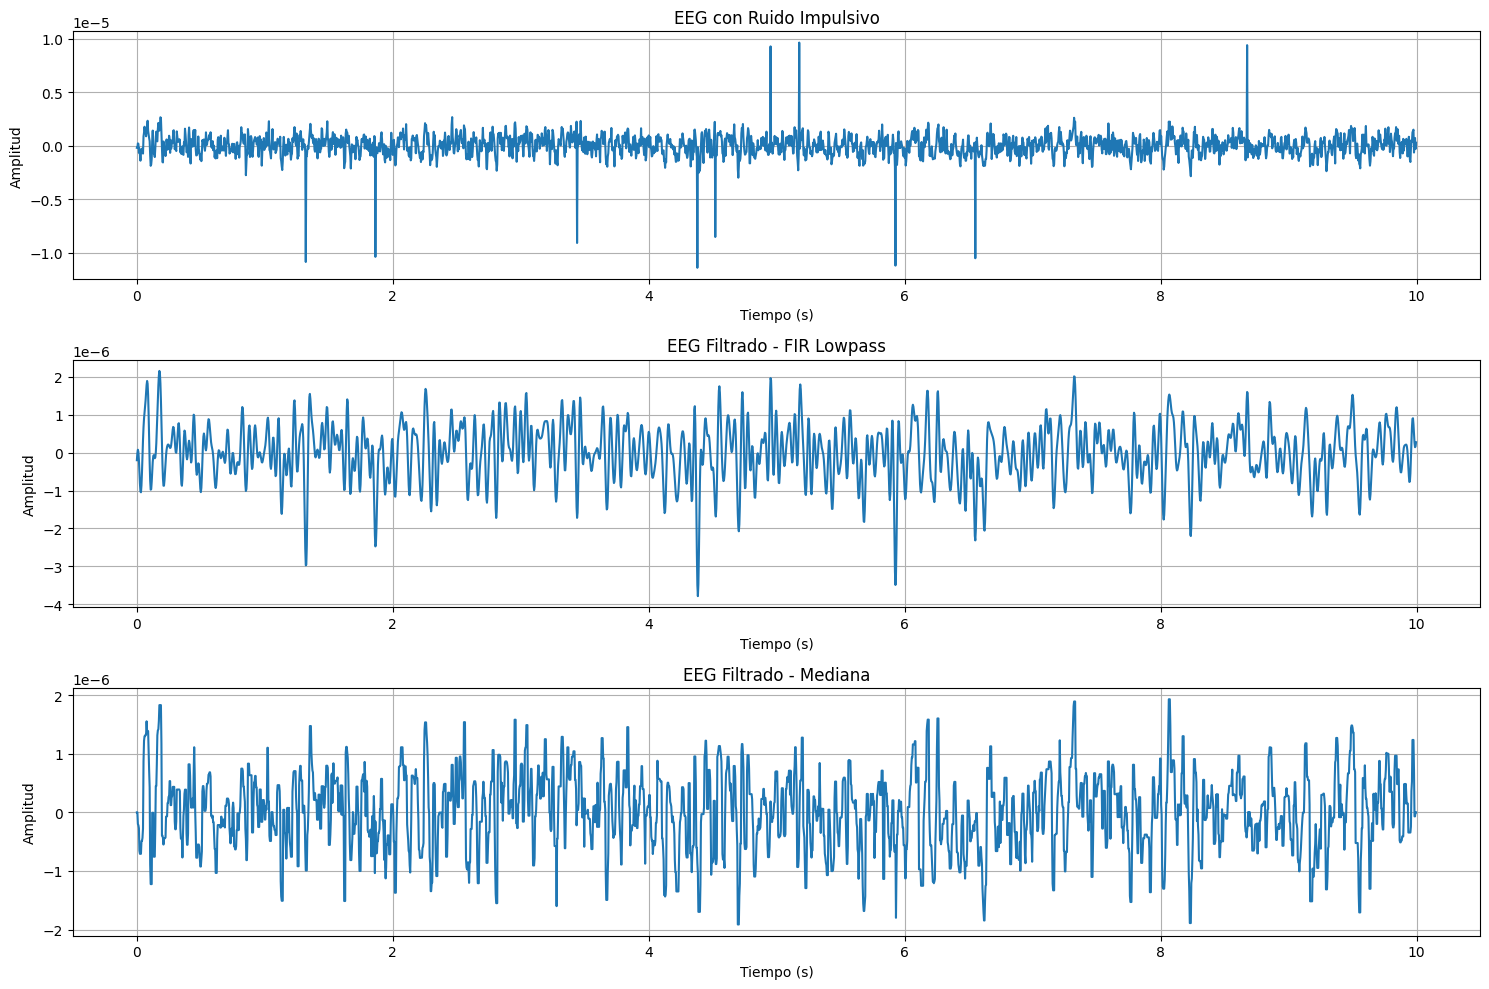

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, freqz, lfilter, firwin, medfilt
import neurokit2 as nk


fs = 250  # Frecuencia de muestreo (Hz)
duration = 10
t = np.linspace(0,duration,int(fs * duration),endpoint=False)

# EEG sintético con NeuroKit2
eeg = nk.eeg_simulate(duration=duration, sampling_rate=fs)

#agregamos los spikes
eeg_noisy = eeg.copy()

np.random.seed(42)

positions = np.random.randint(0,len(eeg),10)

for p in positions:
    eeg_noisy[p] += np.random.choice([1e-5, -1e-5])

#filtro lowpass
cutoff = 30  # Hz

numtaps = 101

fir_coeff = firwin(numtaps,cutoff,fs=fs)

eeg_fir = filtfilt(fir_coeff,[1.0],eeg_noisy)

#filtro mediana
eeg_median = medfilt(eeg_noisy,kernel_size=5)

#gráficas
plt.figure(figsize=(15,10))

# EEG con spikes
plt.subplot(3,1,1)
plt.plot(t, eeg_noisy)
plt.title('EEG con Ruido Impulsivo')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

# FIR
plt.subplot(3,1,2)
plt.plot(t, eeg_fir)
plt.title('EEG Filtrado - FIR Lowpass')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

# Mediana
plt.subplot(3,1,3)
plt.plot(t, eeg_median)
plt.title('EEG Filtrado - Mediana')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

plt.tight_layout()
plt.show()

El filtro de mediana funcionó mejor para eliminar el ruido impulsivo. Esto se debe a que los spikes corresponden a valores atípicos aislados de gran amplitud, y el filtro mediana reemplaza cada muestra por la mediana de sus vecinos, eliminando eficazmente dichos impulsos sin distorsionar significativamente la señal EEG original.

Por otro lado, el filtro FIR lowpass solo atenúa las componentes de alta frecuencia, por lo que los impulsos no desaparecen completamente y además generan oscilaciones alrededor de los spikes. Esto puede observarse en la señal filtrada, donde todavía existen residuos del ruido impulsivo.

# **Ejercicio 4 — Interferencia Eléctrica 60 Hz**
Simule:
*   ECG
*   ruido 60 Hz
*   ruido blanco

Diseñe un pipeline que elimine:

*   Interferencia eléctrica
*   ruido de alta frecuencia

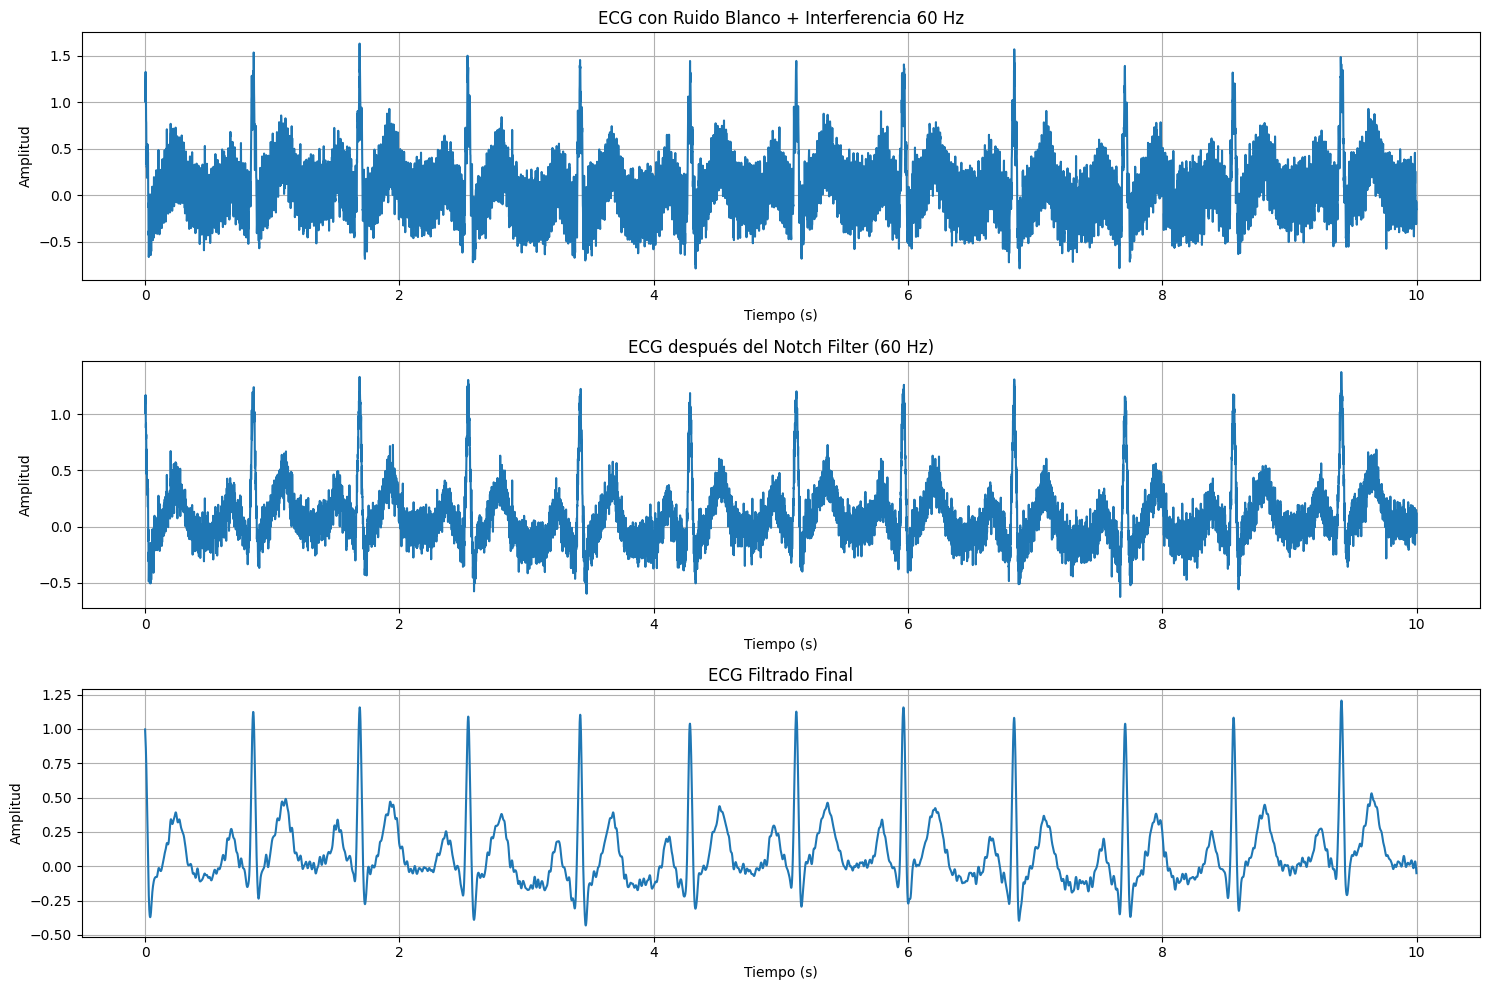

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch
import neurokit2 as nk

fs = 1000
duration = 10

t = np.linspace(0,duration,int(fs*duration),endpoint=False)

# ECG simulado con NeuroKit2

ecg = nk.ecg_simulate(duration=duration,sampling_rate=fs,heart_rate=70,method='ecgsyn')

# Ruido blanco

white_noise = 0.1*np.random.randn(len(ecg))

# Interferencia eléctrica 60 Hz
powerline = 0.3*np.sin(2*np.pi*60*t)

# Señal contaminada
ecg_noisy = ecg + white_noise + powerline

# PIPELINE DE FILTRADO
# NOTCH FILTER (60 Hz)
f0 = 60
Q = 30

b_notch, a_notch = iirnotch(f0,Q,fs)

ecg_notch = filtfilt(b_notch, a_notch,ecg_noisy)

# LOWPASS FILTER

cutoff = 40

order = 4

b_lp, a_lp = butter(order,cutoff,btype='low', fs=fs)

ecg_filtered = filtfilt(b_lp,a_lp,ecg_notch)

# GRÁFICAS
plt.figure(figsize=(15,10))

# ECG contaminado
plt.subplot(3,1,1)
plt.plot(t, ecg_noisy)
plt.title('ECG con Ruido Blanco + Interferencia 60 Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

# Después del notch
plt.subplot(3,1,2)
plt.plot(t, ecg_notch)
plt.title('ECG después del Notch Filter (60 Hz)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

# ECG final
plt.subplot(3,1,3)
plt.plot(t, ecg_filtered)
plt.title('ECG Filtrado Final')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

plt.tight_layout()
plt.show()

# **Ejercicio 5 — Sensores Desincronizados**
Genere:
*   ECG
*   respiración
*   acelerómetro

Cada señal debe tener: delay distinto 2s y ruido gausiano.
Sincronice todas usando correlación cruzada.

Delay ECG estimado: -2.0 s
Delay Respiración estimado: -1.0 s
Delay Acelerómetro estimado: 0.0 s


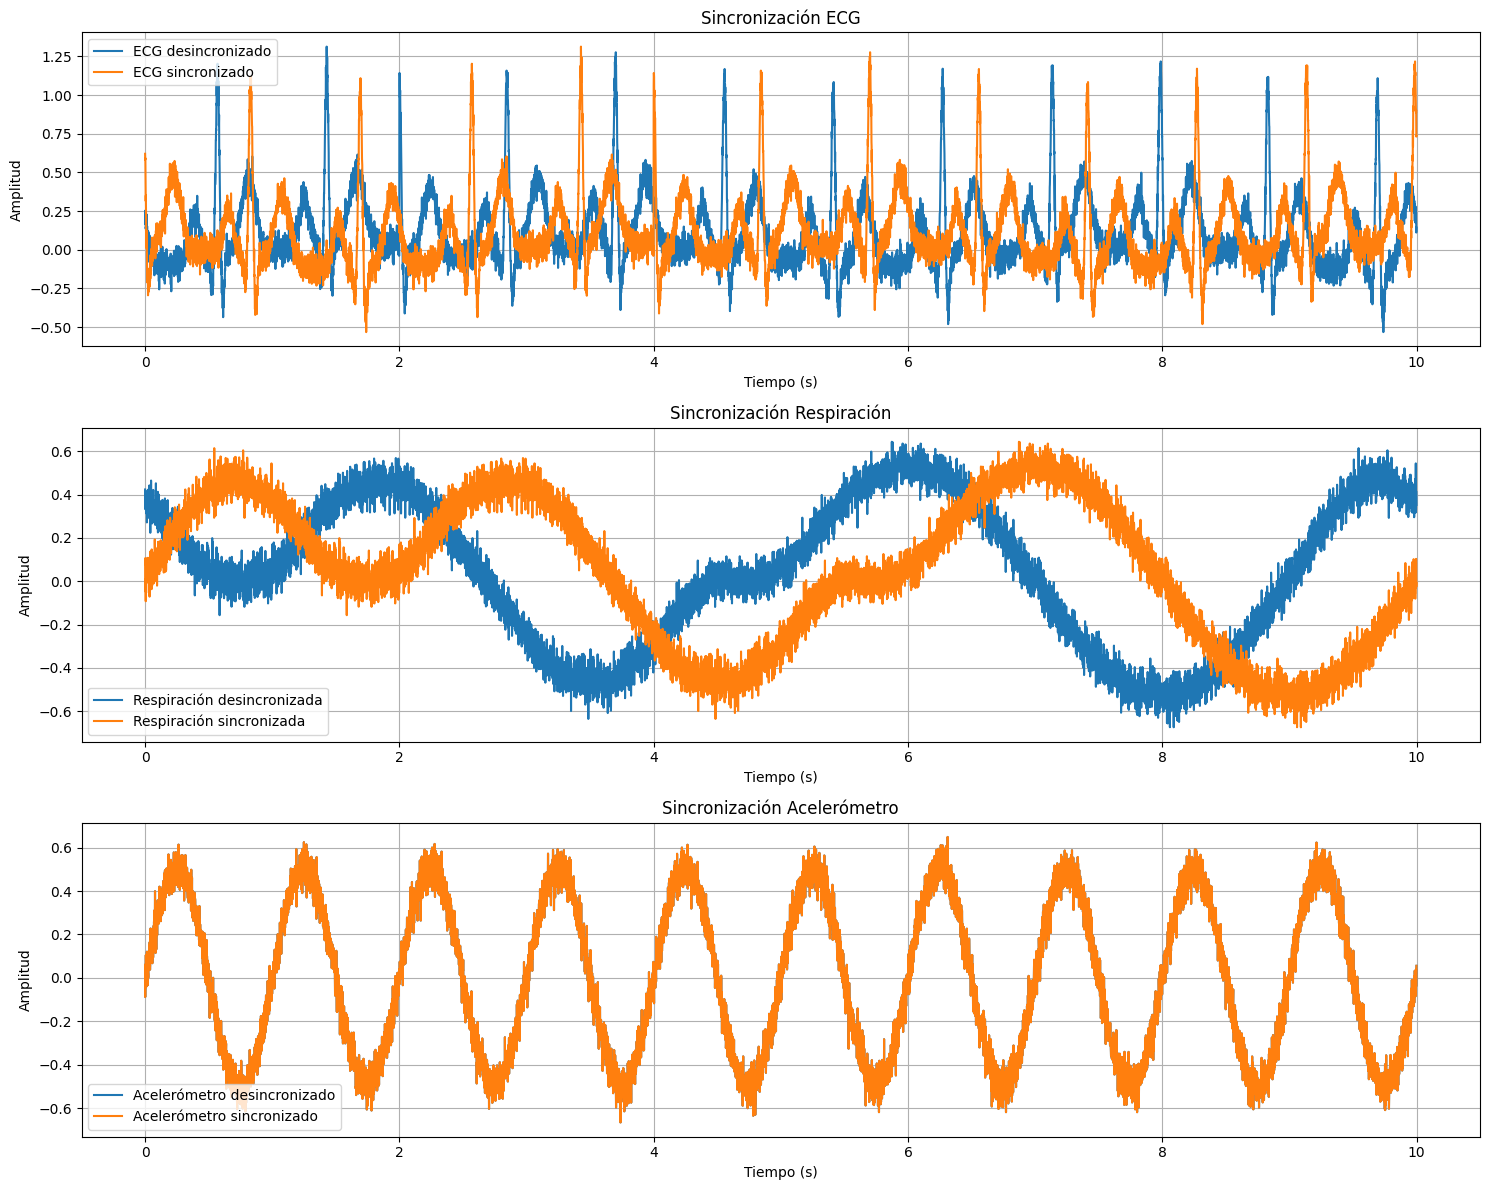

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate
import neurokit2 as nk
s = 1000
duration = 10

t = np.linspace(0,duration,int(fs*duration),endpoint=False)

# ECG simulado con NeuroKit2

ecg = nk.ecg_simulate(duration=duration,sampling_rate=fs,heart_rate=70)

# Respiración
rsp = nk.rsp_simulate(duration=duration,sampling_rate=fs,respiratory_rate=15)

# Acelerómetro artificial
acc = 0.5*np.sin(2*np.pi*1*t)

# Agregar ruido gaussiano
ecg += 0.05*np.random.randn(len(ecg))
rsp += 0.05*np.random.randn(len(rsp))
acc += 0.05*np.random.randn(len(acc))


# Introducir delays distintos
delay_ecg = 2 * fs      # 2 segundos
delay_rsp = 1 * fs      # 1 segundo
delay_acc = 3 * fs      # 3 segundos

ecg_delayed = np.roll(ecg, delay_ecg)
rsp_delayed = np.roll(rsp, delay_rsp)
acc_delayed = np.roll(acc, delay_acc)


# SINCRONIZACIÓN POR CORRELACIÓN CRUZADA
# ECG
corr_ecg = correlate(ecg, ecg_delayed)

estimated_delay_ecg = (np.argmax(corr_ecg) - len(ecg) + 1)

# Respiración
corr_rsp = correlate(rsp, rsp_delayed)

estimated_delay_rsp = (np.argmax(corr_rsp) - len(rsp) + 1)

# Acelerómetro
corr_acc = correlate(acc, acc_delayed)

estimated_delay_acc = (np.argmax(corr_acc) - len(acc) + 1)


# Corregir delays
ecg_sync = np.roll(ecg_delayed,-estimated_delay_ecg)

rsp_sync = np.roll(rsp_delayed, -estimated_delay_rsp)

acc_sync = np.roll(acc_delayed, -estimated_delay_acc)

# RESULTADOS
print("Delay ECG estimado:",estimated_delay_ecg/fs, "s")

print("Delay Respiración estimado:", estimated_delay_rsp/fs, "s")

print("Delay Acelerómetro estimado:",estimated_delay_acc/fs, "s")


# GRÁFICAS
plt.figure(figsize=(15,12))

# ECG
plt.subplot(3,1,1)
plt.plot(t, ecg_delayed, label='ECG desincronizado')

plt.plot(t, ecg_sync, label='ECG sincronizado')

plt.title('Sincronización ECG')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)

# Respiración
plt.subplot(3,1,2)
plt.plot(t, rsp_delayed,label='Respiración desincronizada')

plt.plot(t, rsp_sync, label='Respiración sincronizada')

plt.title('Sincronización Respiración')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)

# Acelerómetro
plt.subplot(3,1,3)
plt.plot(t, acc_delayed, label='Acelerómetro desincronizado')

plt.plot(t, acc_sync, label='Acelerómetro sincronizado')

plt.title('Sincronización Acelerómetro')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#**Ejercicio 6 — Resampling Multisensor**
Simule:
*   ECG a 500 Hz
*   respiración a 100 Hz
*   acelerómetro a 200 Hz

Lleve todas las señales a:
500 Hz y sincronícelas temporalmente

Delay respiración estimado: 0.468 s
Delay acelerómetro estimado: 1.406 s


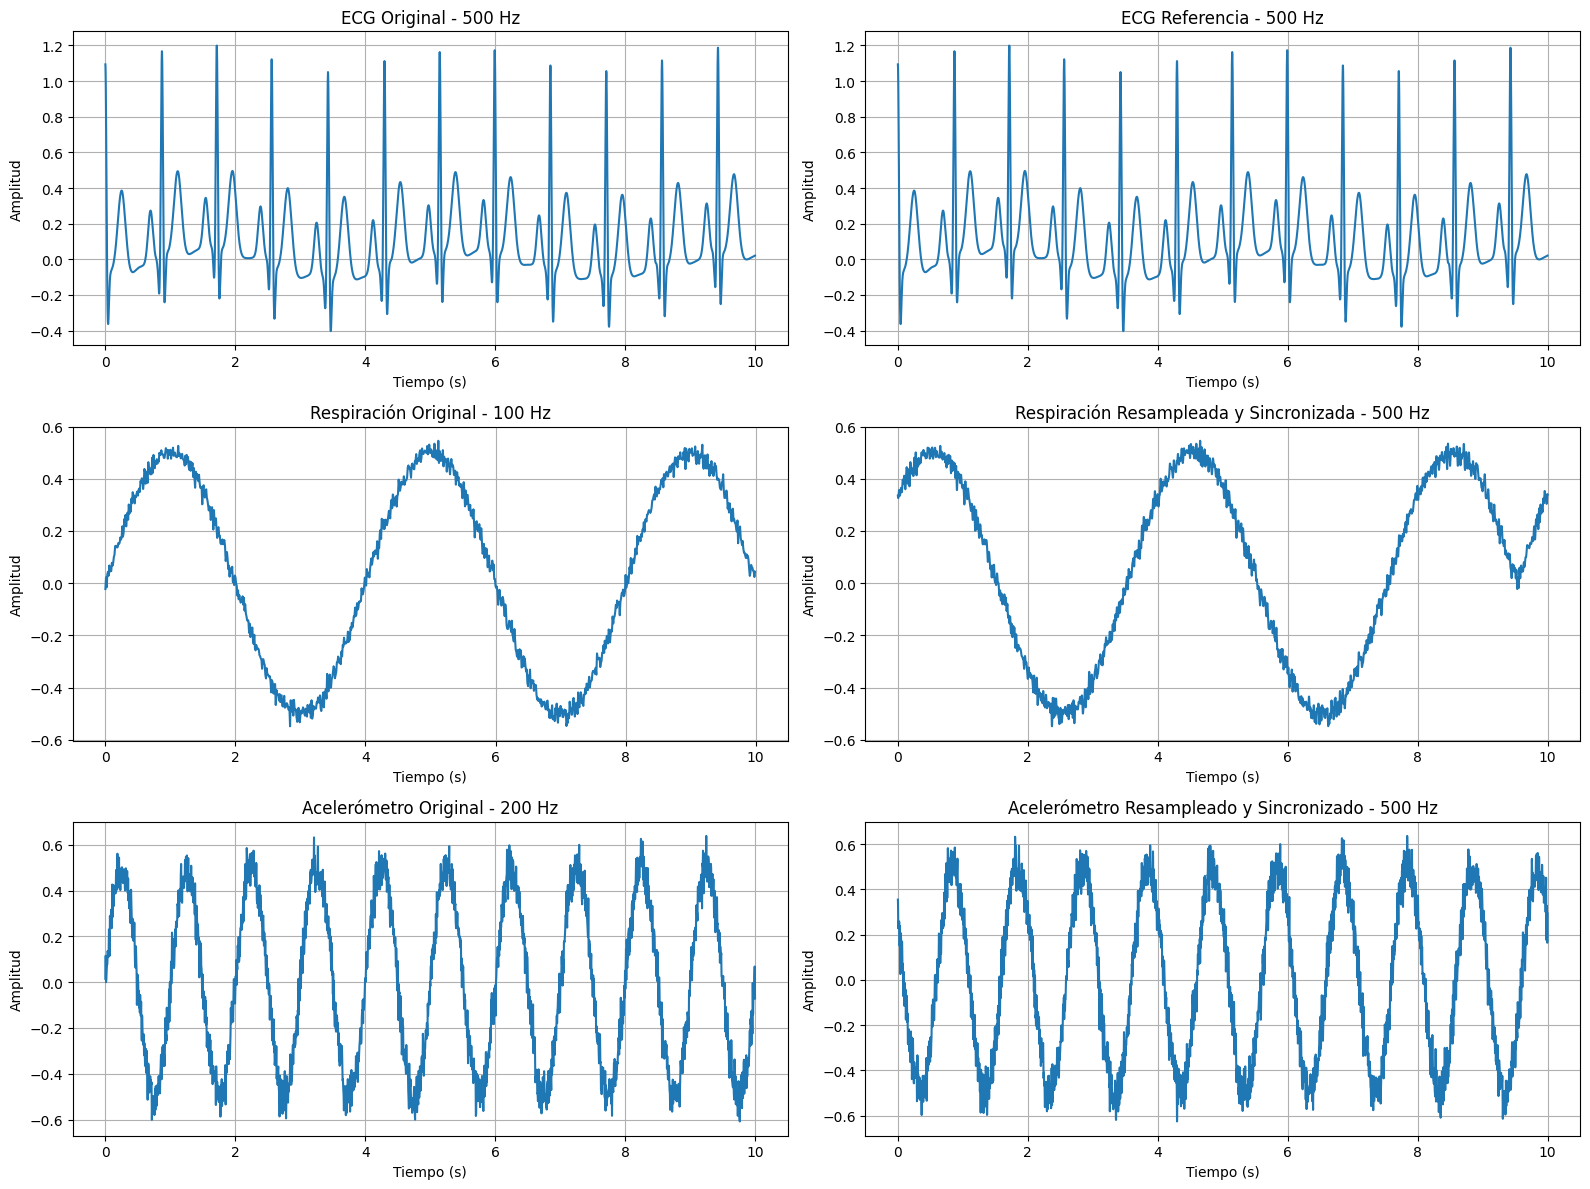

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample, correlate
import neurokit2 as nk

duration = 10

fs_ecg = 500
fs_rsp = 100
fs_acc = 200


# ECG (500 Hz)
t_ecg = np.linspace(0,duration,fs_ecg * duration,endpoint=False)

ecg = nk.ecg_simulate(duration=duration, sampling_rate=fs_ecg, heart_rate=70)

# Respiración (100 Hz)
t_rsp = np.linspace(0, duration, fs_rsp * duration, endpoint=False)

# Respiración
rsp = ( 0.5 * np.sin(2 * np.pi * 0.25 * t_rsp) + 0.02 * np.random.randn(len(t_rsp)))

# Acelerómetro (200 Hz)
t_acc = np.linspace(0,  duration, fs_acc * duration, endpoint=False)

acc = (0.5 * np.sin(2 * np.pi * 1 * t_acc)+ 0.05 * np.random.randn(len(t_acc)))


# RESAMPLING A 500 Hz

# Respiración -> 500 Hz
rsp_resampled = resample(rsp, len(ecg))

# Acelerómetro -> 500 Hz
acc_resampled = resample(acc,len(ecg))

# SINCRONIZACIÓN TEMPORAL

# Respiración
corr_rsp = correlate(ecg, rsp_resampled)

estimated_delay_rsp = ( np.argmax(corr_rsp) - len(ecg) + 1)

rsp_sync = np.roll(rsp_resampled,-estimated_delay_rsp)

# Acelerómetro
corr_acc = correlate(ecg,acc_resampled)

estimated_delay_acc = (np.argmax(corr_acc) - len(ecg) + 1)

acc_sync = np.roll(acc_resampled, -estimated_delay_acc)

# RESULTADOS

print("Delay respiración estimado:", estimated_delay_rsp / fs_ecg,"s")

print("Delay acelerómetro estimado:", estimated_delay_acc / fs_ecg, "s")

fig, axs = plt.subplots(3, 2, figsize=(16, 12))

# Original
axs[0,0].plot(t_ecg, ecg)
axs[0,0].set_title('ECG Original - 500 Hz')
axs[0,0].set_xlabel('Tiempo (s)')
axs[0,0].set_ylabel('Amplitud')
axs[0,0].grid(True)

# Resampleada/Sincronizada
axs[0,1].plot(t_ecg, ecg)
axs[0,1].set_title('ECG Referencia - 500 Hz')
axs[0,1].set_xlabel('Tiempo (s)')
axs[0,1].set_ylabel('Amplitud')
axs[0,1].grid(True)

# Original
axs[1,0].plot(t_rsp, rsp)
axs[1,0].set_title('Respiración Original - 100 Hz')
axs[1,0].set_xlabel('Tiempo (s)')
axs[1,0].set_ylabel('Amplitud')
axs[1,0].grid(True)

# Resampleada
axs[1,1].plot(t_ecg, rsp_sync)
axs[1,1].set_title('Respiración Resampleada y Sincronizada - 500 Hz')
axs[1,1].set_xlabel('Tiempo (s)')
axs[1,1].set_ylabel('Amplitud')
axs[1,1].grid(True)

# Original
axs[2,0].plot(t_acc, acc)
axs[2,0].set_title('Acelerómetro Original - 200 Hz')
axs[2,0].set_xlabel('Tiempo (s)')
axs[2,0].set_ylabel('Amplitud')
axs[2,0].grid(True)

# Resampleado
axs[2,1].plot(t_ecg, acc_sync)
axs[2,1].set_title('Acelerómetro Resampleado y Sincronizado - 500 Hz')
axs[2,1].set_xlabel('Tiempo (s)')
axs[2,1].set_ylabel('Amplitud')
axs[2,1].grid(True)

plt.tight_layout()
plt.show()

In [18]:
import nbformat as nbf

nb = nbf.read("lab8_ana.ipynb", as_version=4)

if "widgets" in nb["metadata"]:
    del nb["metadata"]["widgets"]

nbf.write(nb, "lab8_ana_clean.ipynb")

FileNotFoundError: [Errno 2] No such file or directory: 'lab8_ana.ipynb'